In [6]:
import numpy as np
import json
from data.dataset import LandmarksDataset, ToTensorWithSeg
from data.transforms import Scale
from models.hybridgnet_se_resnext_dual import HybridDual
from models.hybridgnet_se_resnext import Hybrid
from models.utils import load_config
from torchvision import transforms
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
import matplotlib.gridspec as gridspec
import os

In [72]:
DATASET = '../Dataset/Merged/Landmarks_3_10'
NAME = 'Merged'

hyperparameters = json.load(open("../Trained/Fetal/%s/hyperparameters.json"%NAME))
hyperparameters['naive'] = True

config, D_t, U_t, A_t = load_config(DATASET, hyperparameters)
config['resume'] = "../Trained/Fetal/%s/%s.pth"%(NAME, NAME)
config['raster_as_input'] = False

if config['use_dual']:
    model = HybridDual(config, D_t, U_t, A_t).to(config['device'])
else:
    model = Hybrid(config, D_t, U_t, A_t).to(config['device'])

print("Image Encoder filters", model.encoder.filters + [model.encoder.filters[-1]])
print("Bottleneck latents", model.encoder.latents)
print("Graph convolutional filters", config['filters'][::-1])

if config['resume']:
    model.load_checkpoint(config['resume'], config['device'])

model.eval()

images = os.listdir("../Dataset/JNU-IFM/Landmarks_3_10/images")

# Obtain patients by splitting with "_" and taking the first part
patients = set(img.split('_')[0] for img in images if img.endswith('.png') or img.endswith('.jpg'))
print("Number of patients:", len(patients))

Loading adjacency matrices ../Dataset/Merged/Landmarks_3_10/Naive/adj_full_block_diagonal.npy
Image Encoder filters [16, 32, 64, 128, 256, 256]
Bottleneck latents 64
Graph convolutional filters [32, 32, 24, 24, 16, 16, 8, 2]
Number of patients: 78


In [98]:
import matplotlib.pyplot as plt
import numpy as np
import random
from utils.image_processing import draw_lines, draw_organ

# Load organ IDs

if config["naive"]:
    organ_id = np.load("%s/Naive/adj_full_organ_id.npy" % DATASET)[:,0]
    organ_order = np.unique(organ_id)
else:
    # Load organ IDs
    organ_id = np.load("%s/NonNaive/adj_full_organ_id.npy" % DATASET)[:,0]

    unique_organs = set()
    for org_str in organ_id:
        for org in str(org_str).split('-'):
            if org:  # Skip empty strings
                unique_organs.add(org)

    organ_order = sorted(list(unique_organs))
    
    with open(f"{DATASET}/NonNaive/organ_order_full.json", "r") as f:
        circ_organ_order = json.load(f)
print("Organ order:", organ_order)

# Enable interactive mode
plt.ion()

# sample three patients 
patients_predictions = []

for i in range(4):
    patient = patients.pop()
    print(f"Processing patient: {patient}")
    
    images_patient = [img for img in images if img.startswith(patient)]
    # images are patient_time, sort them by time naturally using numbers 
    # 19 should come before 101
    images_patient.sort(key=lambda x: (x.split('_')[0], int(x.split('_')[1].split('.')[0])))
    images_patient = [img for img in images_patient if img.endswith('.png') or img.endswith('.jpg')]
    print("Number of images:", len(images_patient))

    val_dataset = LandmarksDataset(images_patient, "%s/images"%DATASET, "%s/landmarks"%DATASET, 
                                transform = transforms.Compose([Scale(config['inputsize']), ToTensorWithSeg()]))

    predictions = {'patient': patient}

    # For each randomly selected pair of samples
    for idx in range(0, len(val_dataset)):
        sample1 = val_dataset[idx]
        
        image1, landmarks1, raster1 = sample1['image'], sample1['landmarks'], sample1['raster']
        
        # Run model inference
        out1 = model(image1.unsqueeze(0).to(config['device']))[0]
        out1 = out1 * config['inputsize']
        output1 = out1.squeeze(0).cpu().detach().numpy()
        
        img1 = image1.squeeze(0).cpu().detach().numpy()
        organs1 = landmarks1[:, 2].cpu().numpy()
        
        if not "image" in predictions:
            predictions["image"] = []
        if not "target" in predictions:
            predictions["target"] = []
        predictions["image"].append(img1)
        predictions["target"].append(raster1.cpu().detach().numpy())
        
        # Plot each organ
        for organ in organ_order:
            # Get indices for this organ
            if config["naive"]:
                idx_organ = organ_id == organ
            else:
                idx_organ = np.zeros(output1.shape[0], dtype=bool)
                idx_organ[circ_organ_order[organ]] = True
            
            idx_target1 = organs1 == organ
            
            if int(organ) not in predictions:
                predictions[int(organ)] = []
            predictions[int(organ)].append(output1[idx_organ])
            
        
            print(f"Processed sample {idx + 1}/{len(val_dataset)} for organ {organ}")
    patients_predictions.append(predictions)

Organ order: [1. 2.]
Processing patient: 20191127T110427
Number of images: 68
Processed sample 1/68 for organ 1.0
Processed sample 1/68 for organ 2.0
Processed sample 2/68 for organ 1.0
Processed sample 2/68 for organ 2.0
Processed sample 3/68 for organ 1.0
Processed sample 3/68 for organ 2.0


/home/ngaggion/miniconda3/envs/hybridgnet/lib/python3.13/site-packages/torch/nn/modules/instancenorm.py:115: UserWarning: input's size at dim=1 does not match num_features. You can silence this warning by not passing in num_features, which is not used because affine=False
  warnings.warn(


Processed sample 4/68 for organ 1.0
Processed sample 4/68 for organ 2.0
Processed sample 5/68 for organ 1.0
Processed sample 5/68 for organ 2.0
Processed sample 6/68 for organ 1.0
Processed sample 6/68 for organ 2.0
Processed sample 7/68 for organ 1.0
Processed sample 7/68 for organ 2.0
Processed sample 8/68 for organ 1.0
Processed sample 8/68 for organ 2.0
Processed sample 9/68 for organ 1.0
Processed sample 9/68 for organ 2.0
Processed sample 10/68 for organ 1.0
Processed sample 10/68 for organ 2.0
Processed sample 11/68 for organ 1.0
Processed sample 11/68 for organ 2.0
Processed sample 12/68 for organ 1.0
Processed sample 12/68 for organ 2.0
Processed sample 13/68 for organ 1.0
Processed sample 13/68 for organ 2.0
Processed sample 14/68 for organ 1.0
Processed sample 14/68 for organ 2.0
Processed sample 15/68 for organ 1.0
Processed sample 15/68 for organ 2.0
Processed sample 16/68 for organ 1.0
Processed sample 16/68 for organ 2.0
Processed sample 17/68 for organ 1.0
Processed sam

Pubic Symphysis shape: (68, 64, 2)
Fetal Head shape: (68, 136, 2)
Pubic Symphysis shape: (46, 64, 2)
Fetal Head shape: (46, 136, 2)
Pubic Symphysis shape: (56, 64, 2)
Fetal Head shape: (56, 136, 2)
Pubic Symphysis shape: (63, 64, 2)
Fetal Head shape: (63, 136, 2)


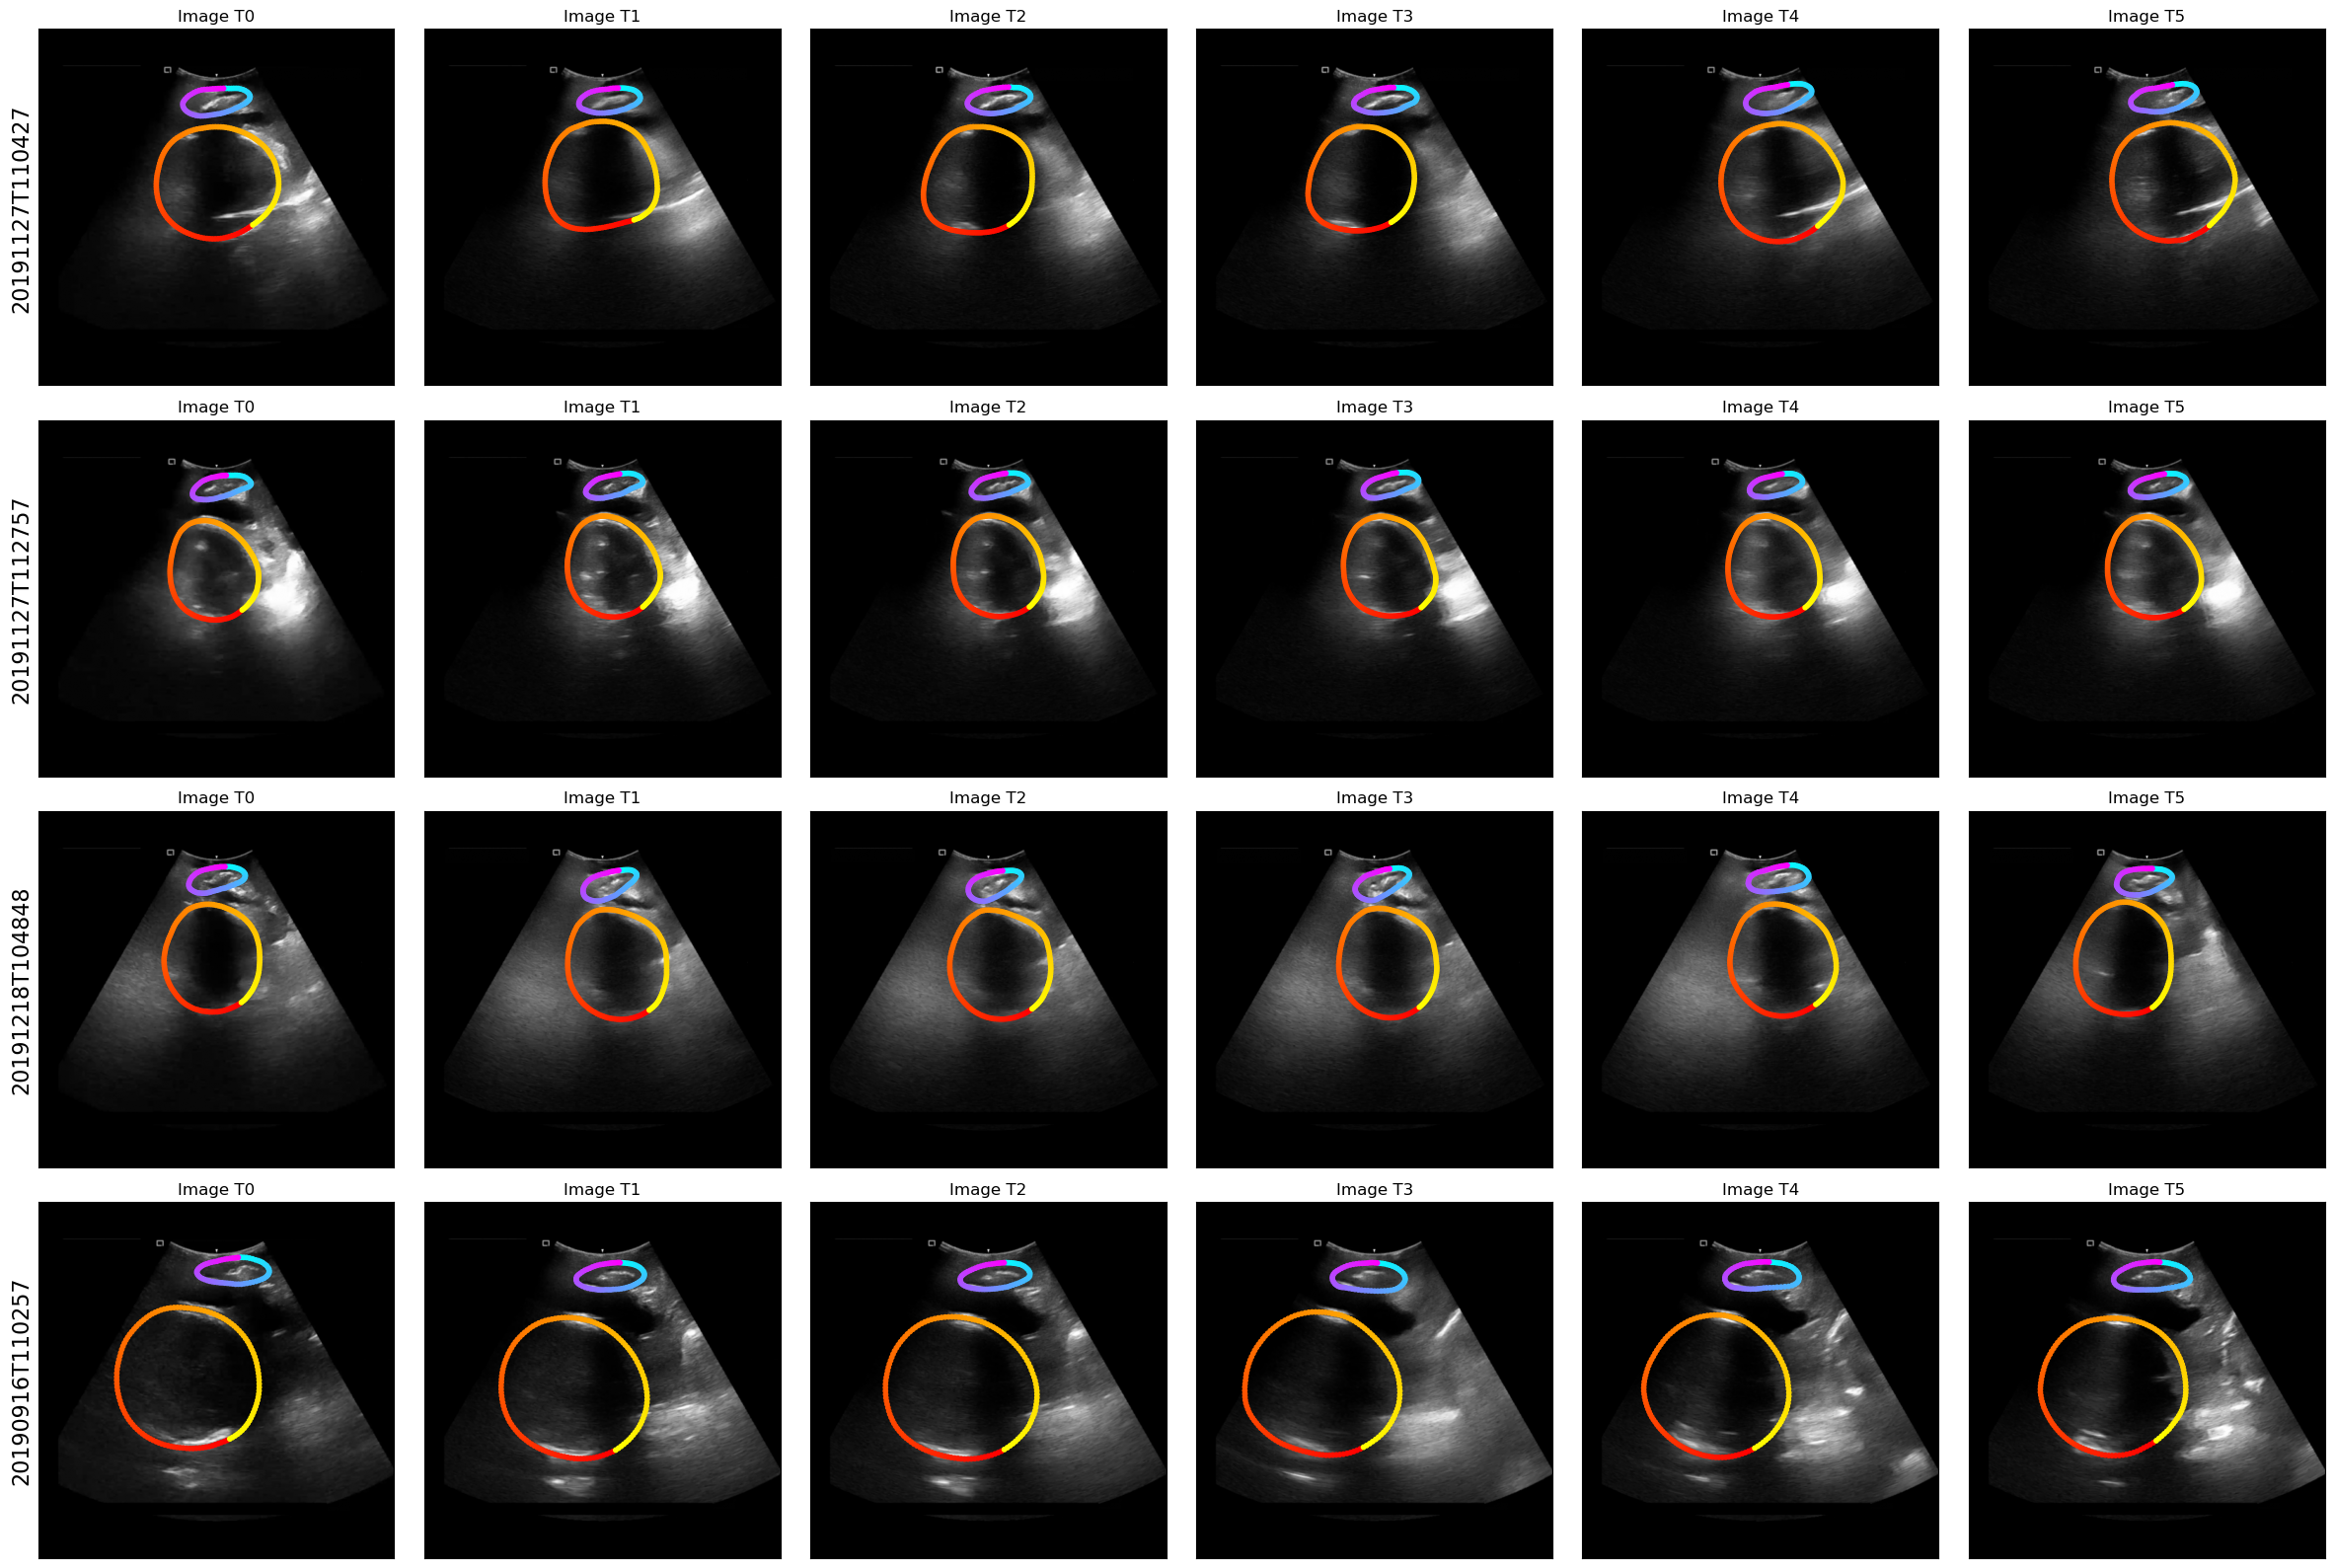

In [110]:
fig = plt.figure(figsize=(24, 16))

j = 0
for predictions in patients_predictions:
    pubic_symphysis = predictions[1]
    fetal_head = predictions[2]
    patient = predictions["patient"]

    # concatenate all predictions for each organ in a new axis
    # so they are T, N, 2
    pubic_symphysis = np.stack(pubic_symphysis, axis=0)
    fetal_head = np.stack(fetal_head, axis=0)

    print("Pubic Symphysis shape:", pubic_symphysis.shape)
    print("Fetal Head shape:", fetal_head.shape)

    # i want to plot image at t0, t1, t2, t3 and the corresponding predictions
    # for pubic symphysis and fetal head

    # predictions are landmark for each image at each time, so draw the images with the predictions scattered on top
    
    for i in range(6):
        ax1 = fig.add_subplot(4, 6, i + 1 + j * 6)
        
        # Plot image
        img = predictions["image"][i]
        target = predictions["target"][i]
        
        # Plot pubic symphysis
        ax1.imshow(img, cmap='gray')
        # color code the nodes using their index in hsv
        ax1.scatter(pubic_symphysis[i, :, 0], pubic_symphysis[i, :, 1], 
                    c=np.arange(pubic_symphysis.shape[1]), cmap='cool', s=10)  # Use HSV colormap for distinct colors
        
        # color code the nodes using their index in hsv
        ax1.scatter(fetal_head[i, :, 0], fetal_head[i, :, 1], 
                    c=np.arange(fetal_head.shape[1]), cmap='autumn', s=10)  # Use 'x' marker for fetal head
        
        ax1.set_title(f"Image T{i}")
        
        if i==0:
            ax1.set_ylabel(f"{patient}", fontsize=16)
        
        ax1.set_xticks([])
        ax1.set_yticks([])
    plt.tight_layout()
    j+= 1

plt.savefig("/home/ngaggion/Documents/Mask2Graph/Dataset/JNU-IFM/FetalHeadPredictions.png", bbox_inches='tight', dpi=300)
